In [334]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,log_loss,confusion_matrix,classification_report





In [335]:
df=pd.read_csv(r'C:\Users\Lenovo\OneDrive\Desktop\practice\ML-LogisticRegression.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [336]:
df.shape

(1470, 35)

In [337]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [338]:
df.duplicated().sum()

np.int64(0)

In [339]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [340]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [341]:
df.describe(exclude='number')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [342]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [343]:
cols_to_drop=[]
for c in ['EmployeeCount','EmployeeNumber','Over18','StandardHours']:
    if c in df.columns:
        cols_to_drop.append(c)

    
df=df.drop(cols_to_drop,axis=1)




In [344]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [345]:
numeric_col=df.select_dtypes(include='number').columns.to_list()
numeric_col

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [346]:
categorical_col=df.select_dtypes(include='object').columns.to_list()
categorical_col

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [347]:
df.Attrition.value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

<Axes: xlabel='Attrition', ylabel='count'>

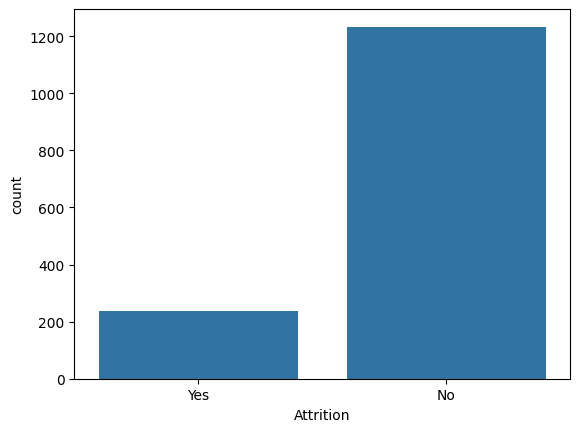

In [348]:
#attrition 
sns.countplot(x=df['Attrition'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2984\3507547365.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,6))


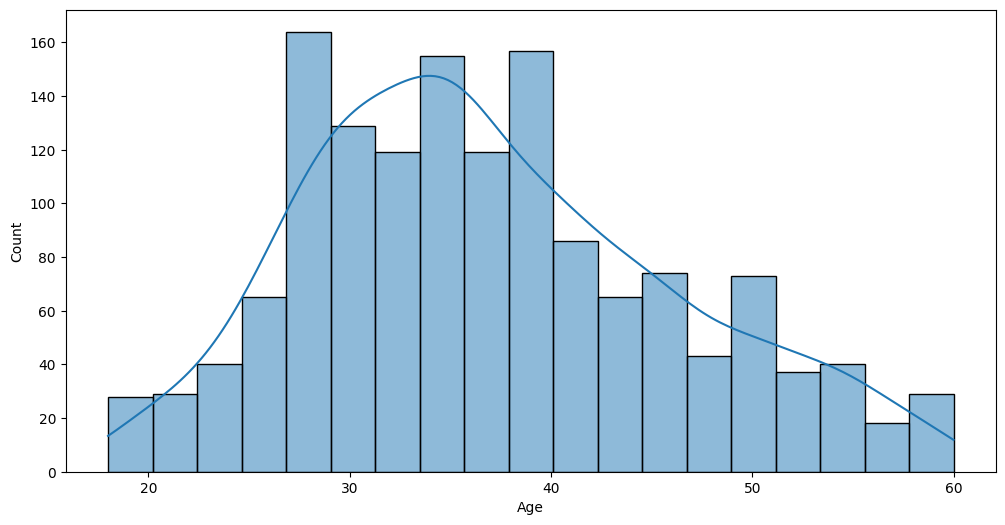

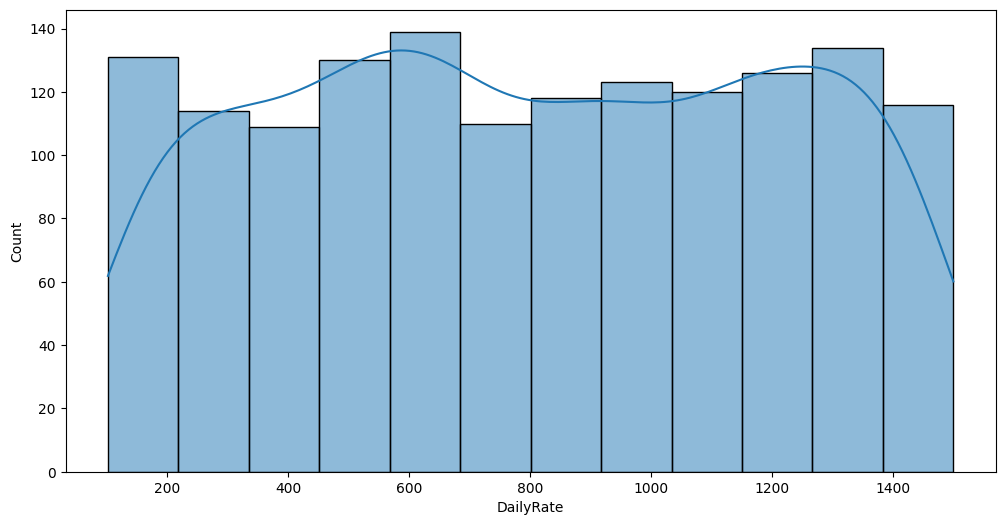

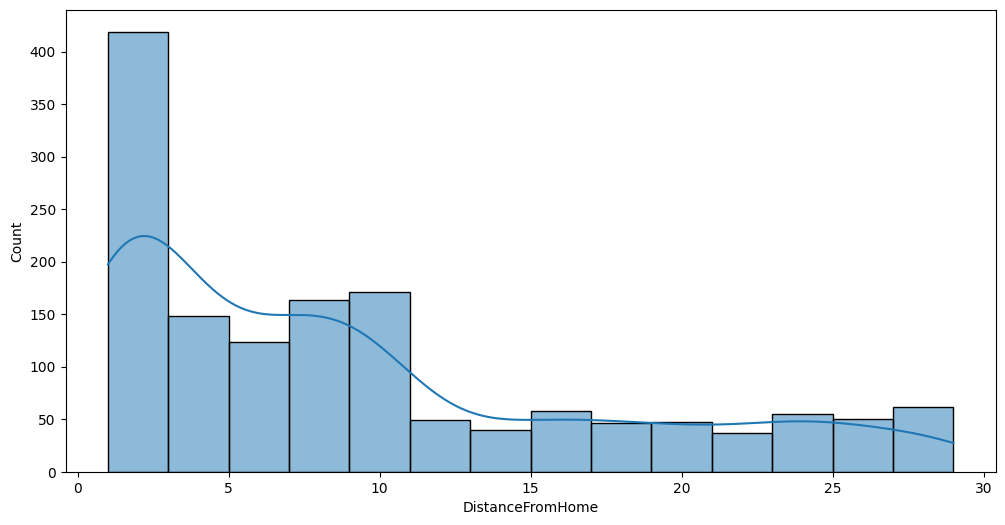

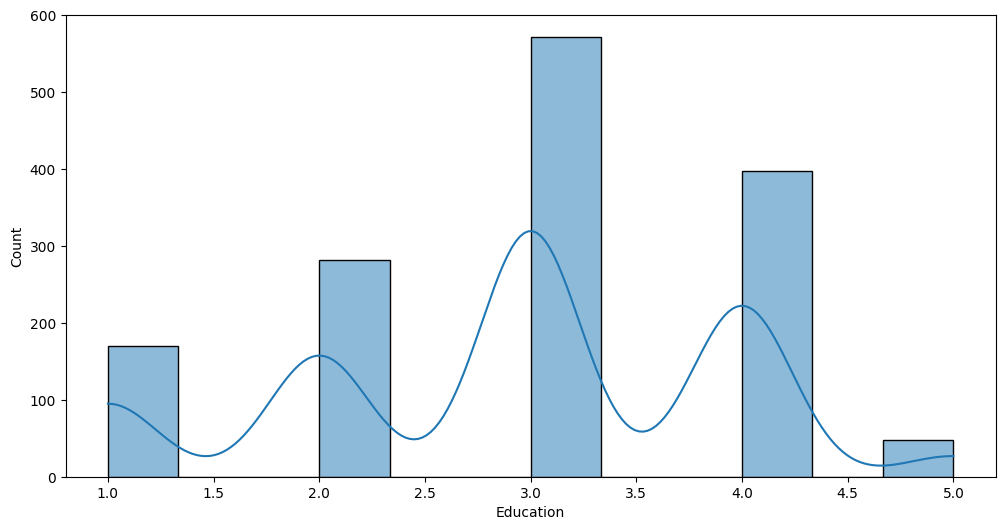

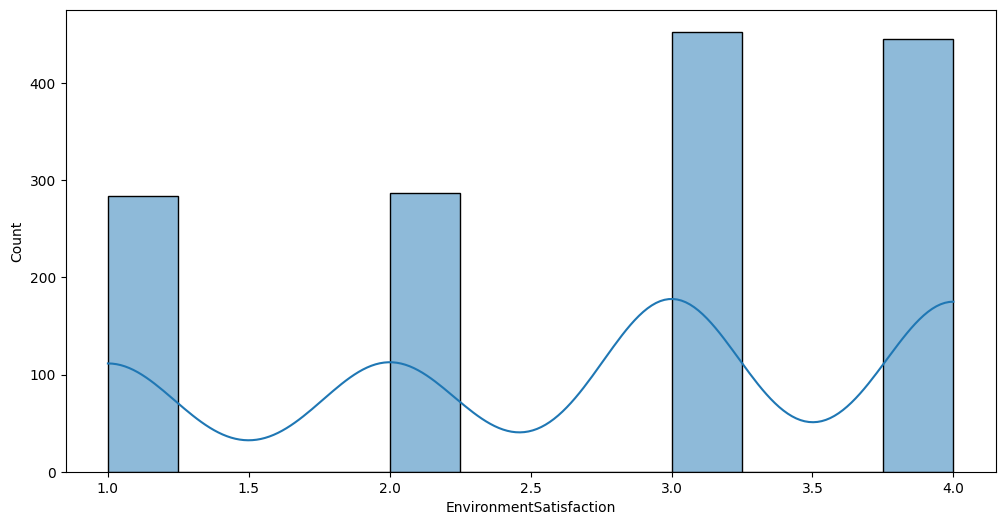

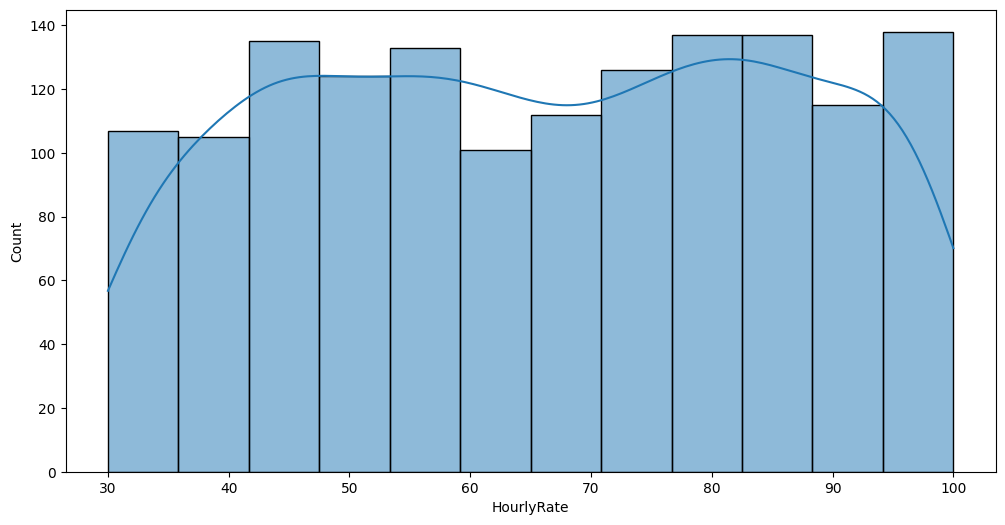

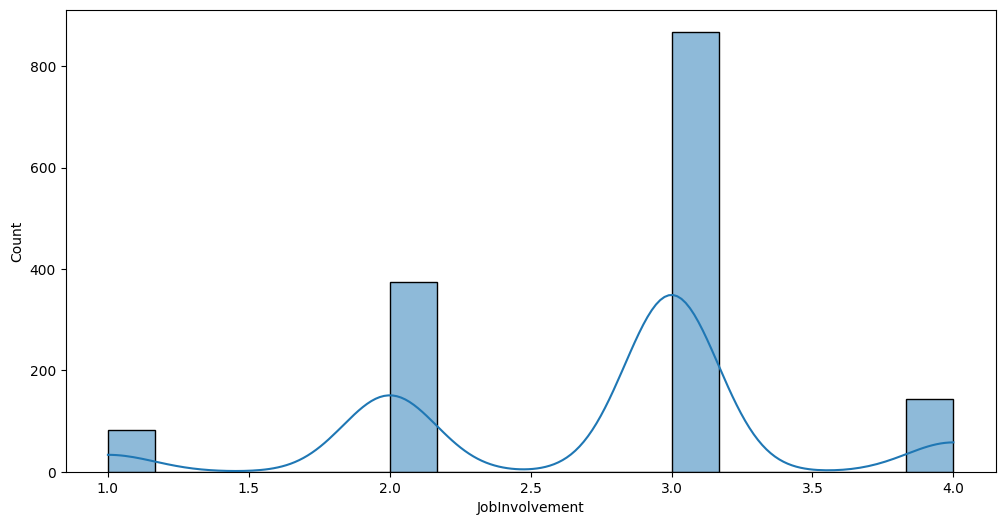

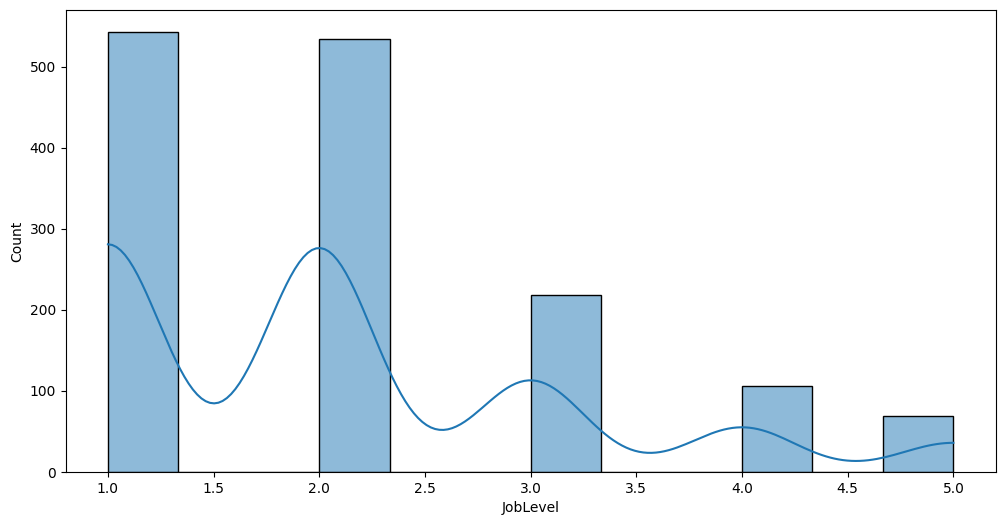

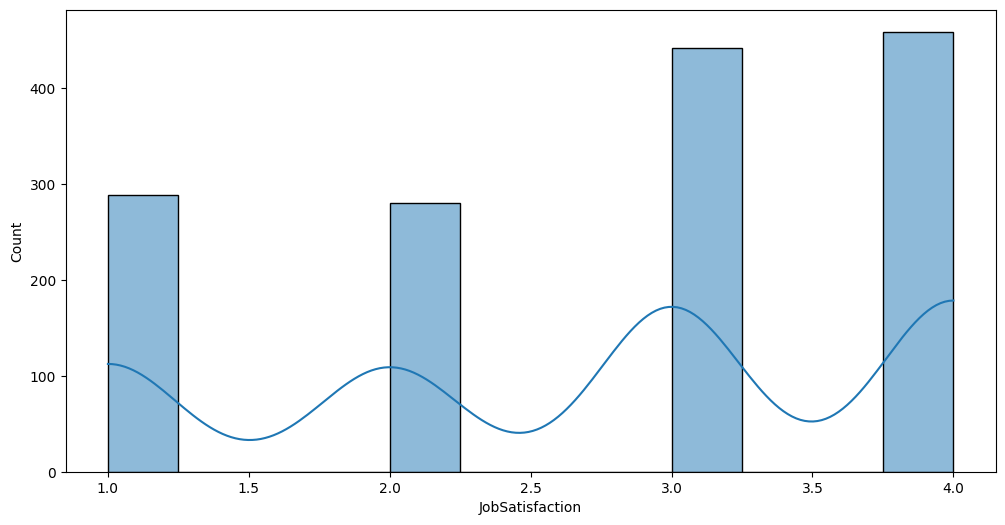

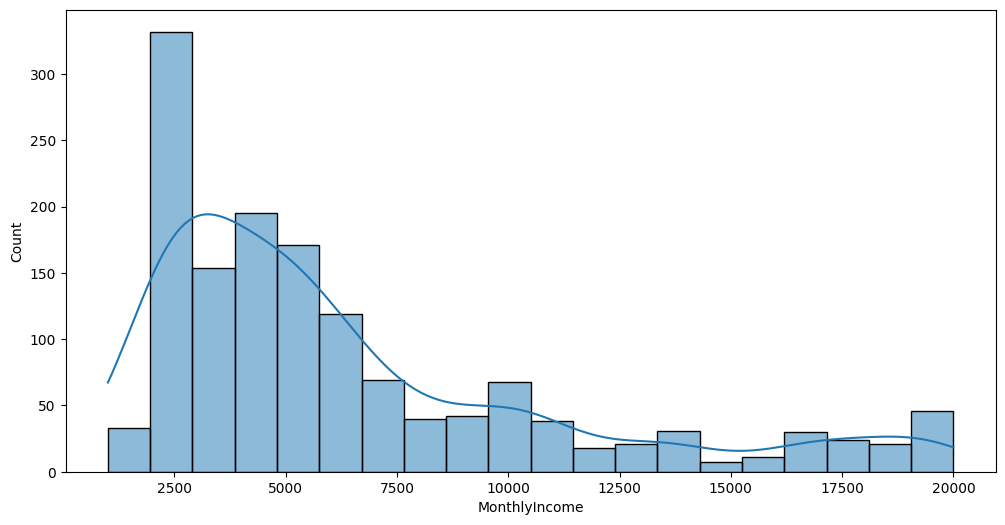

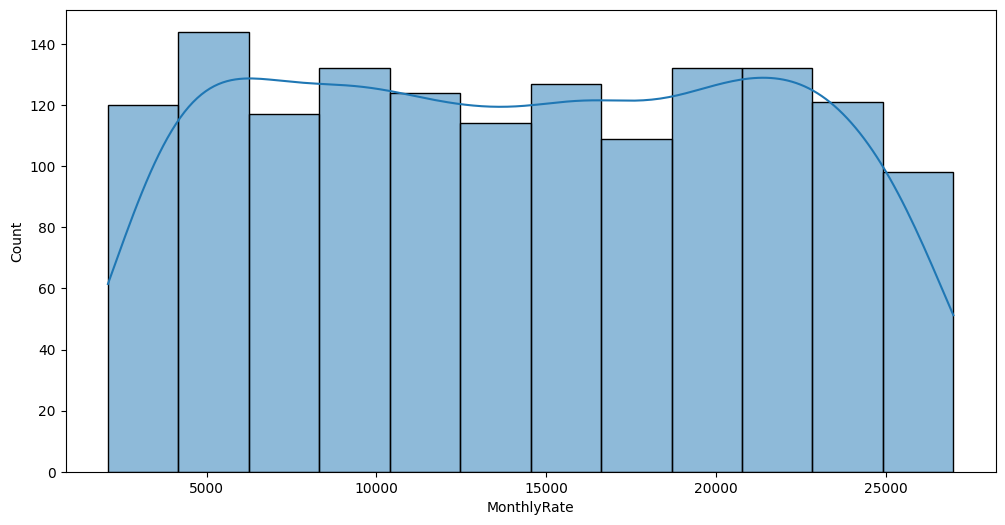

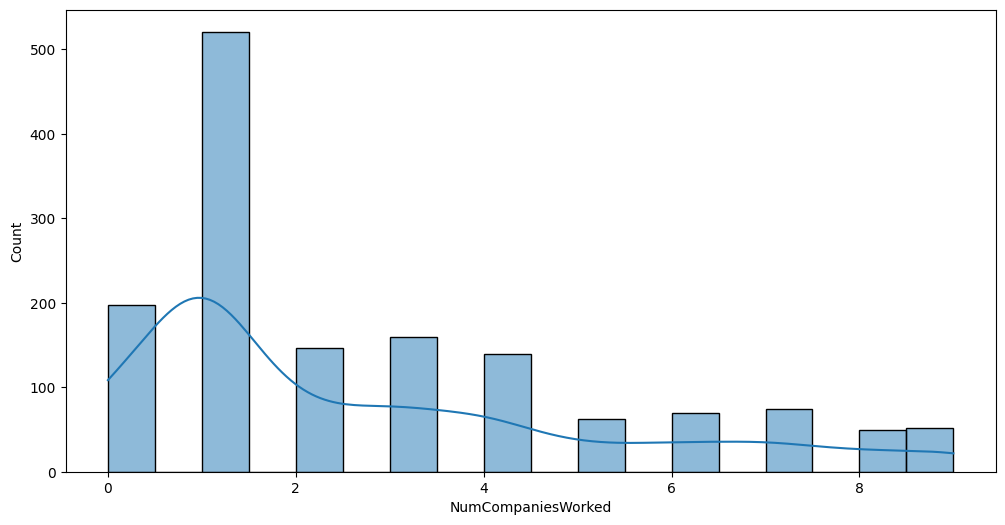

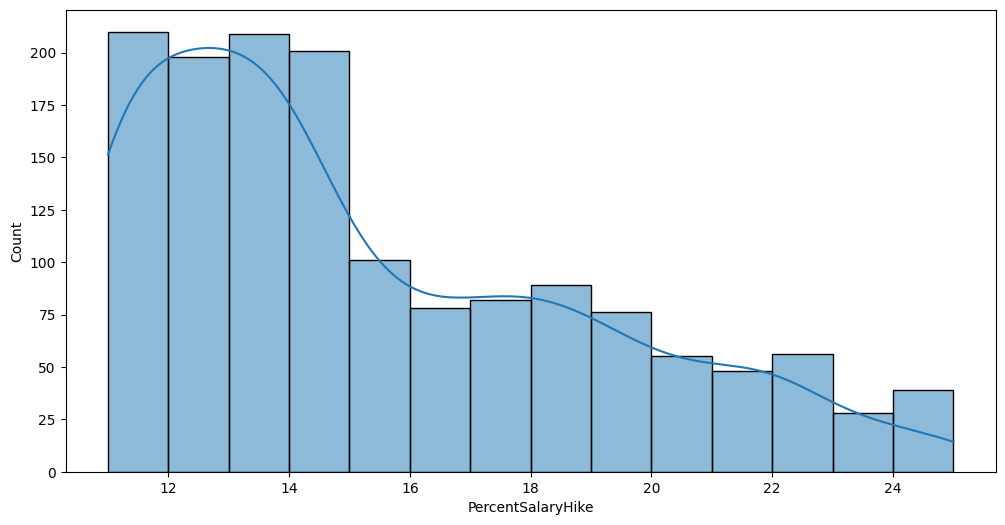

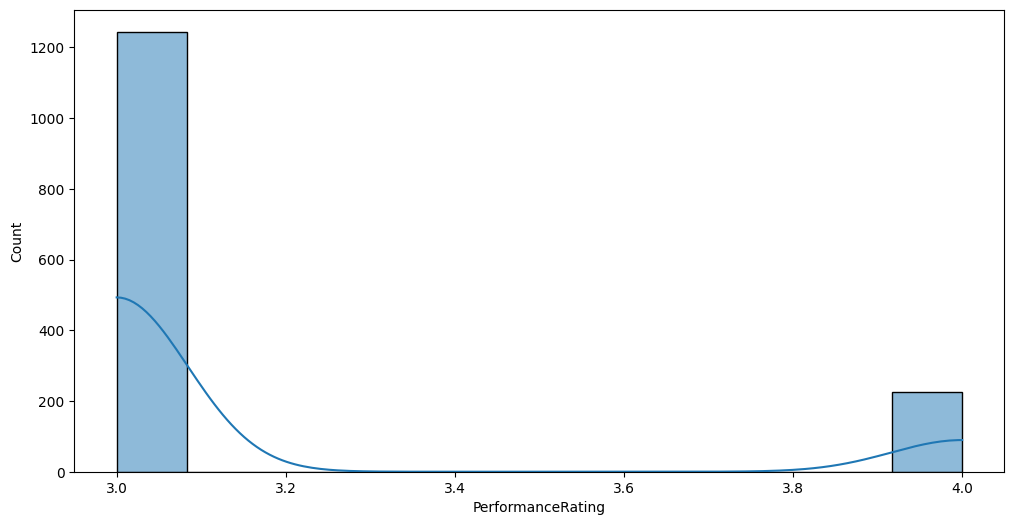

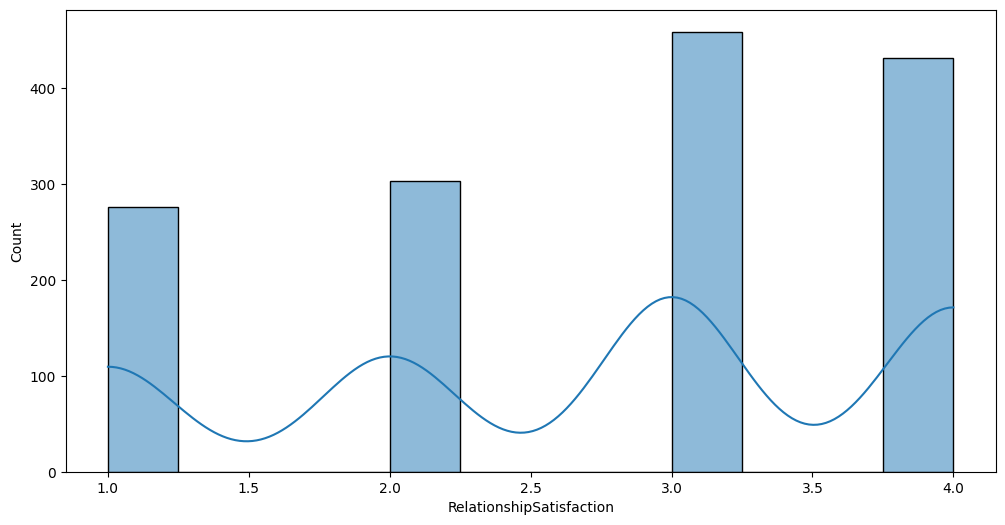

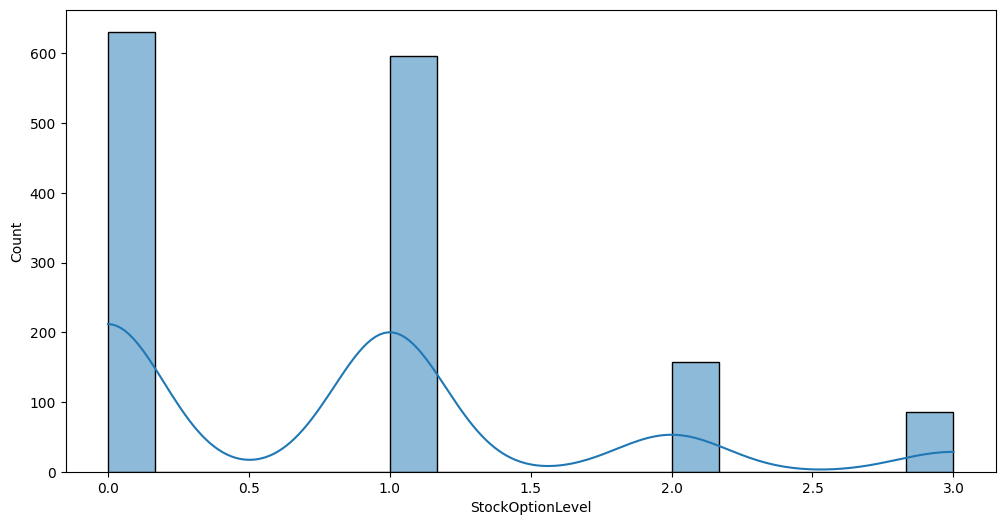

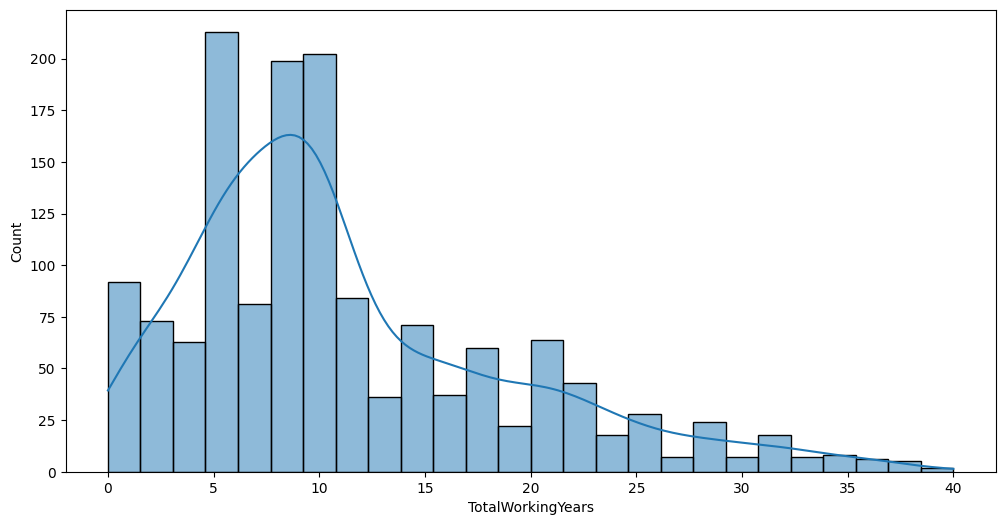

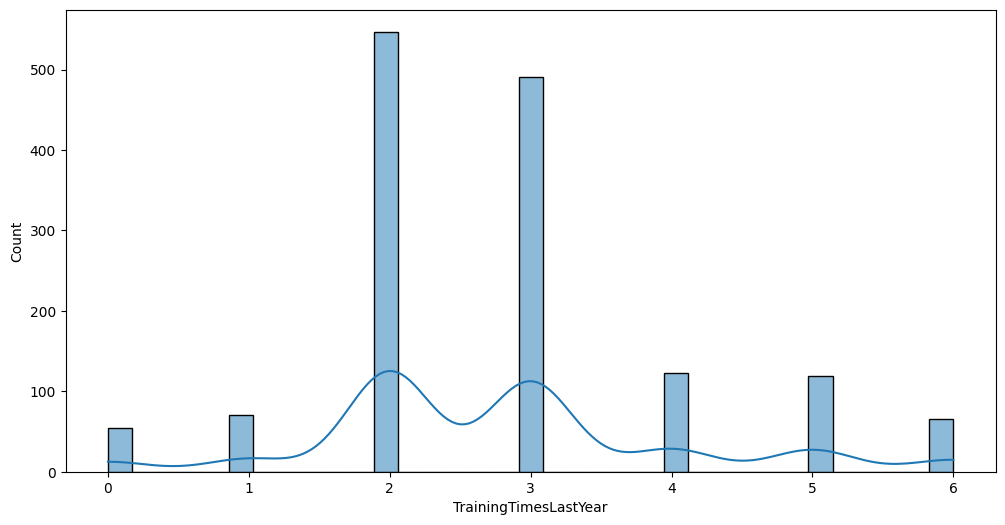

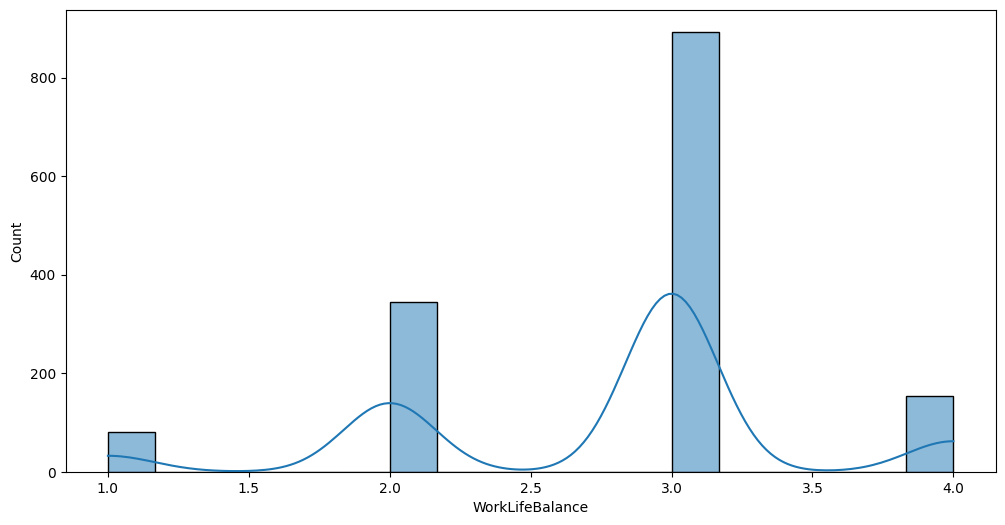

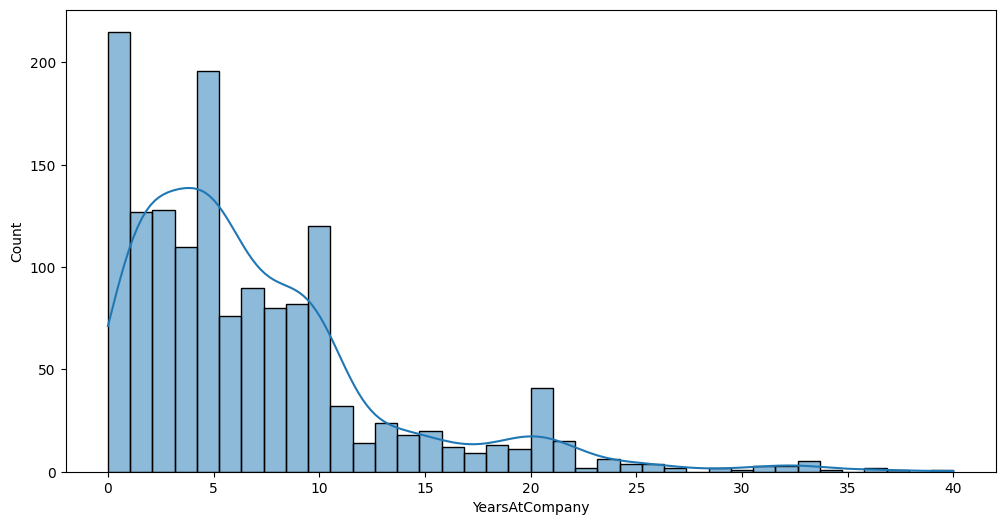

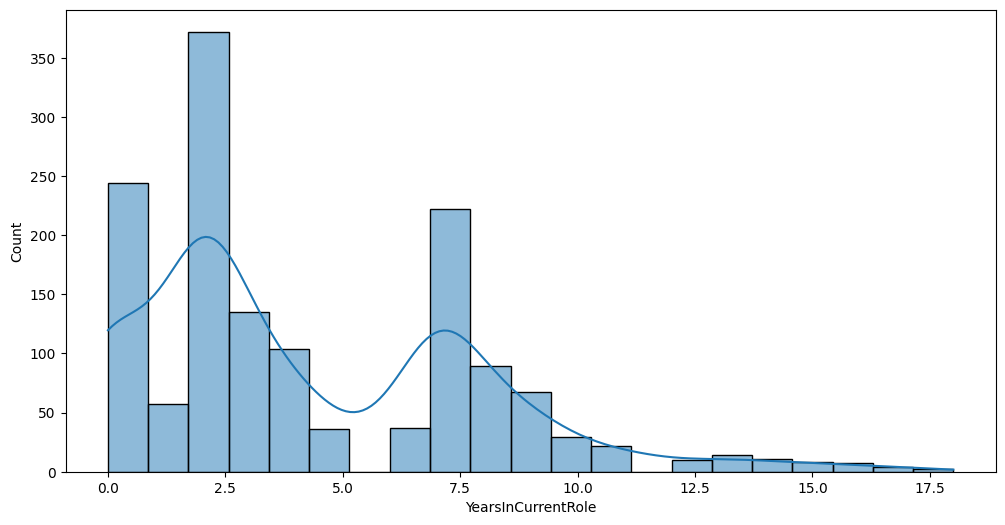

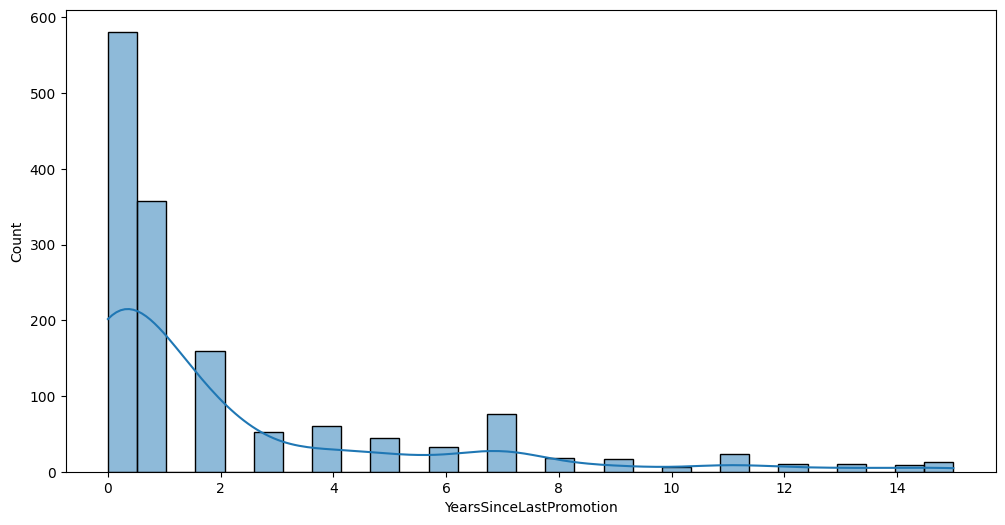

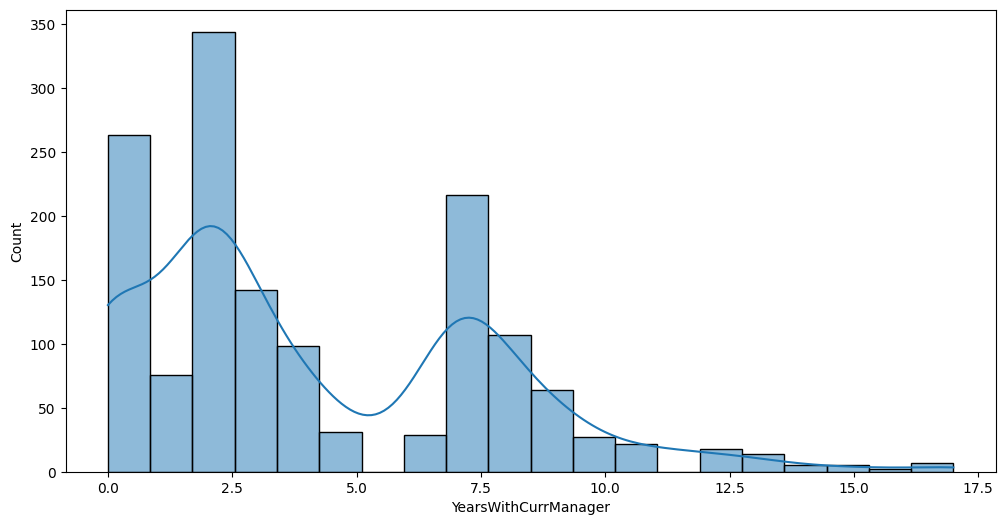

In [349]:
for i in numeric_col:
    plt.figure(figsize=(12,6))
    sns.histplot(x=df[i],kde=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2984\3780892760.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,6))


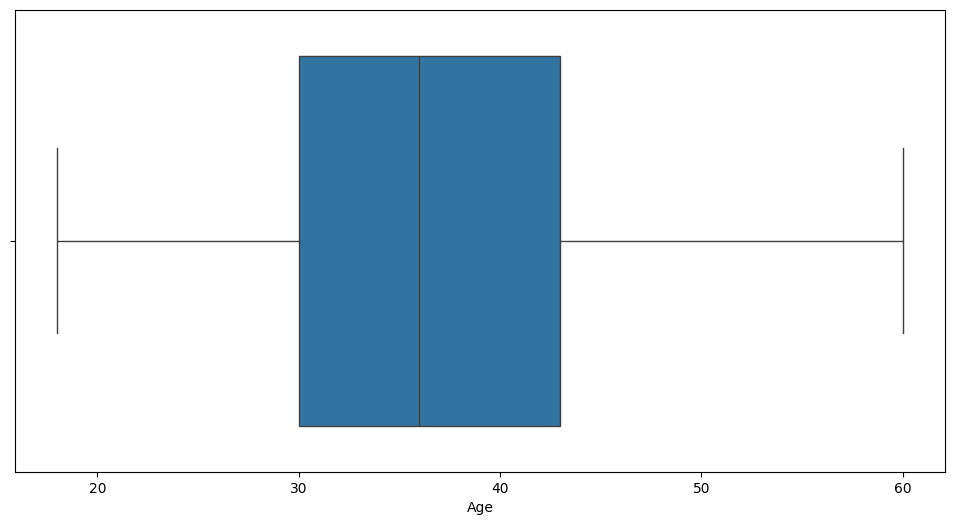

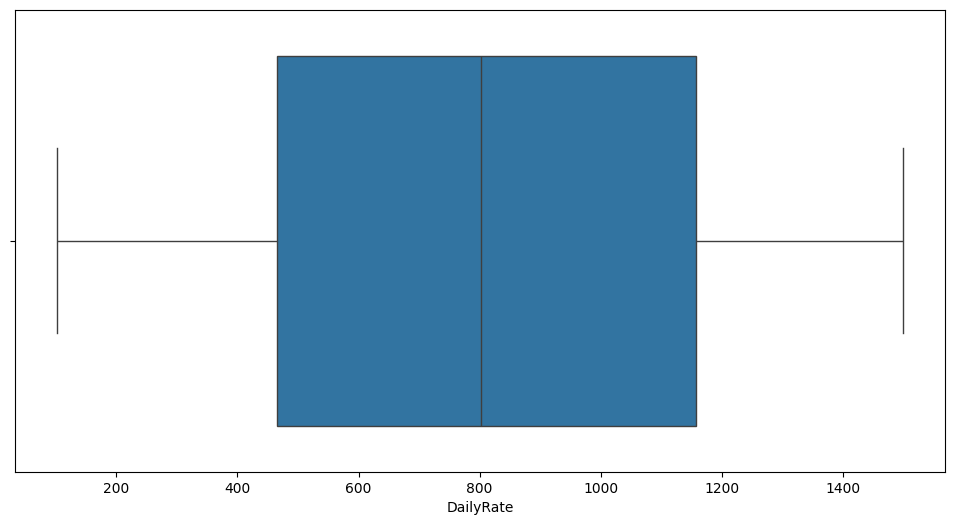

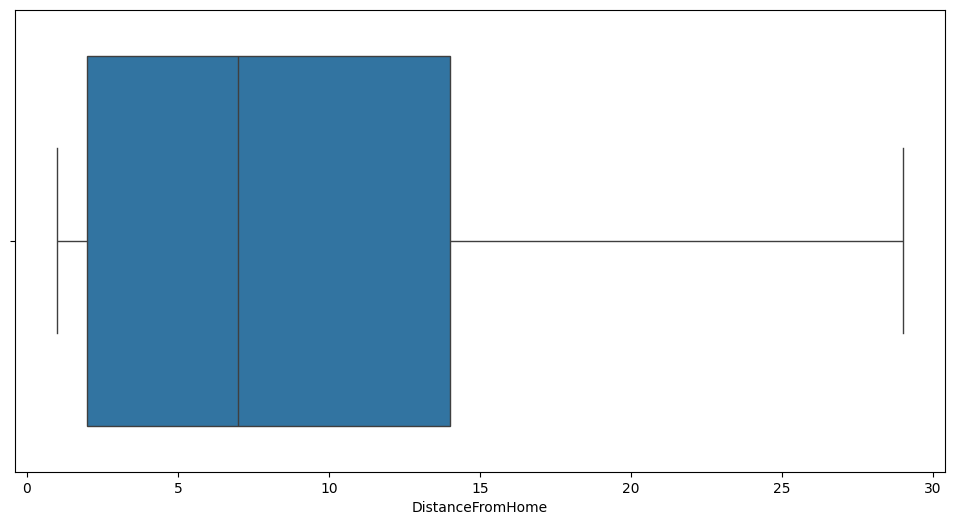

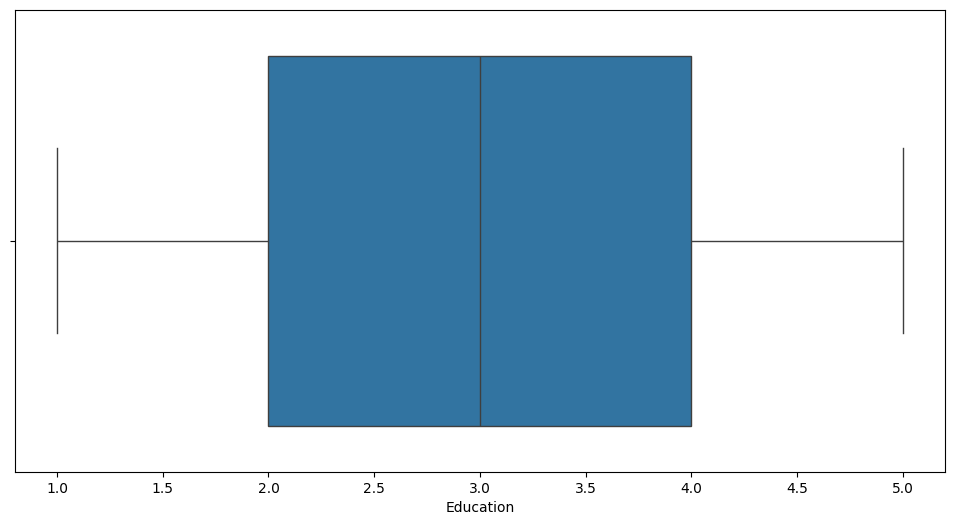

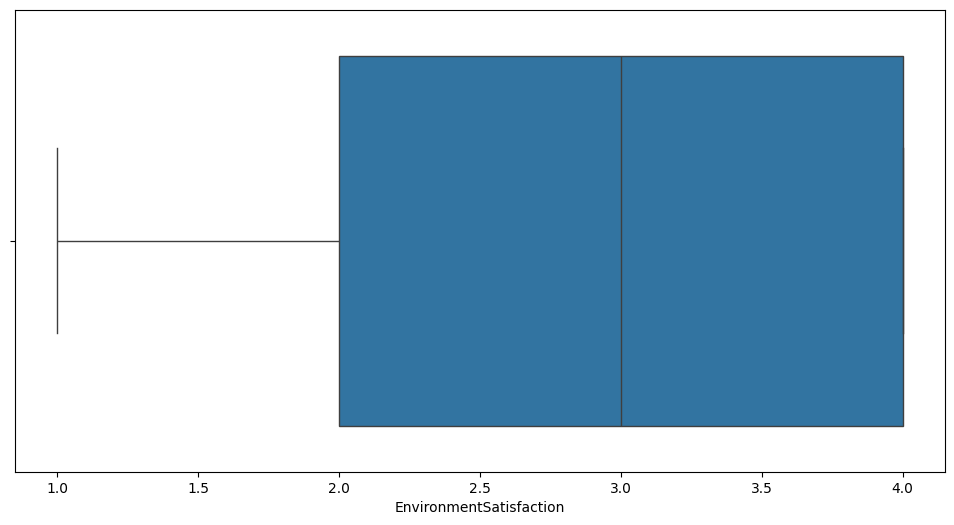

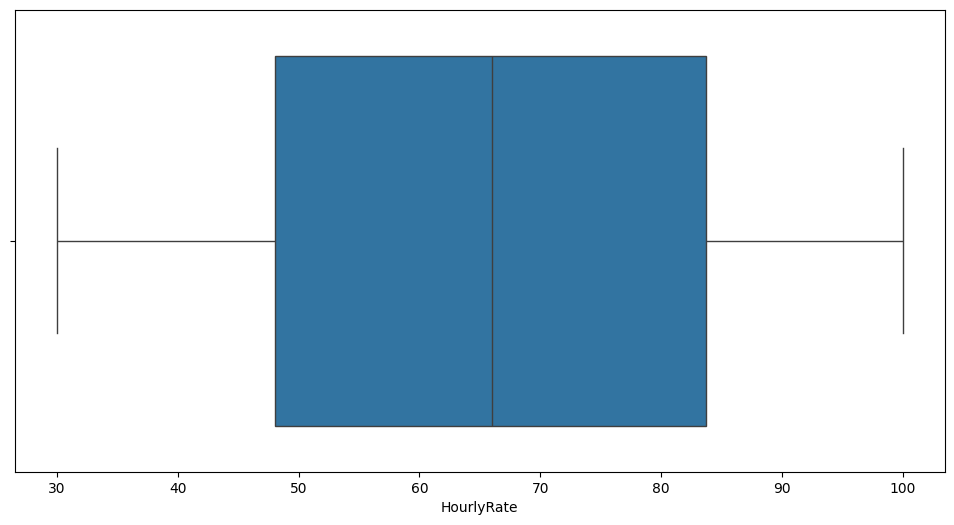

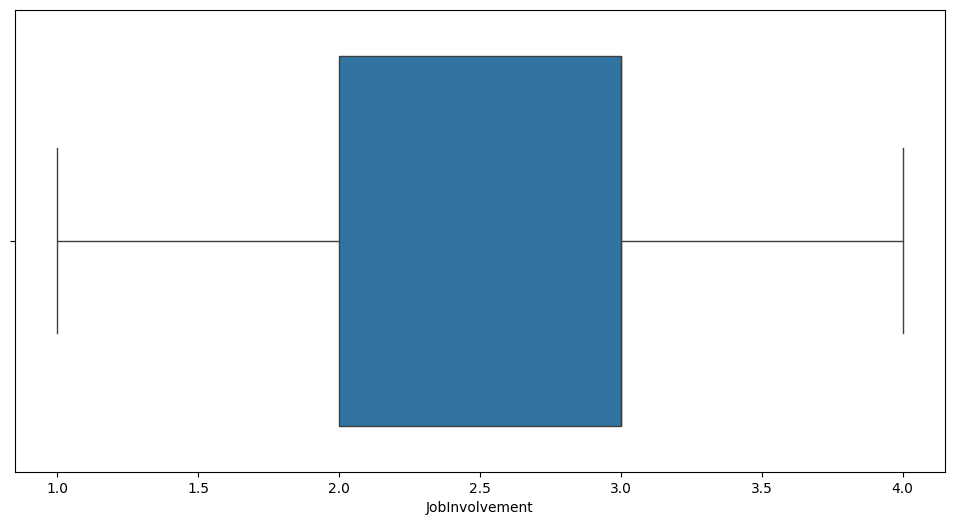

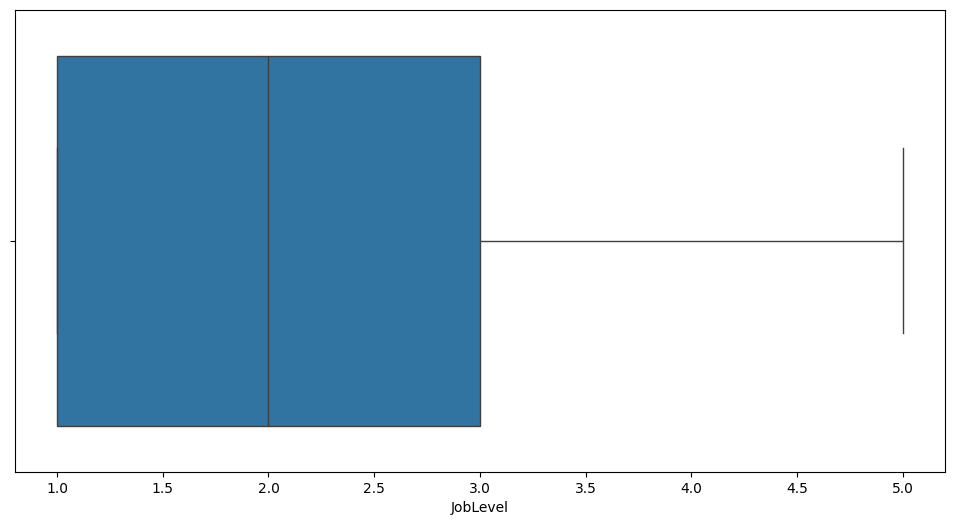

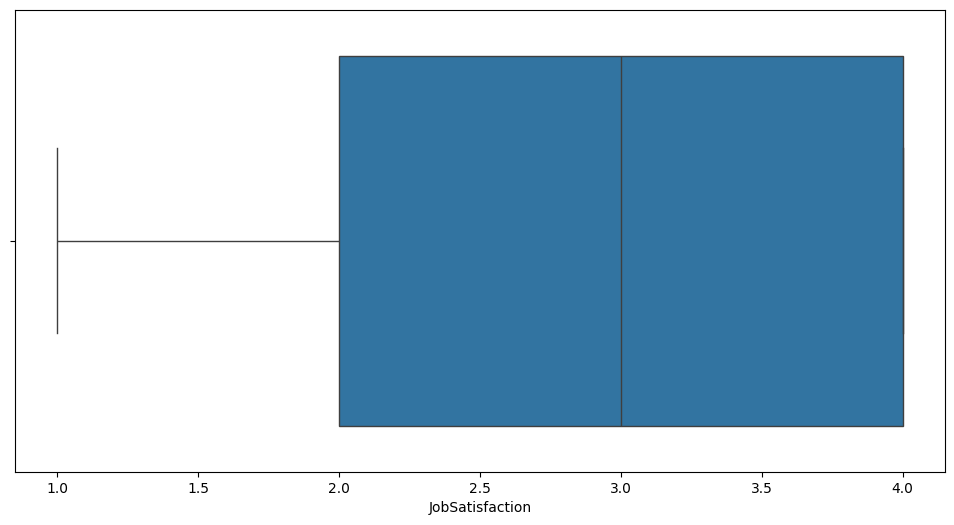

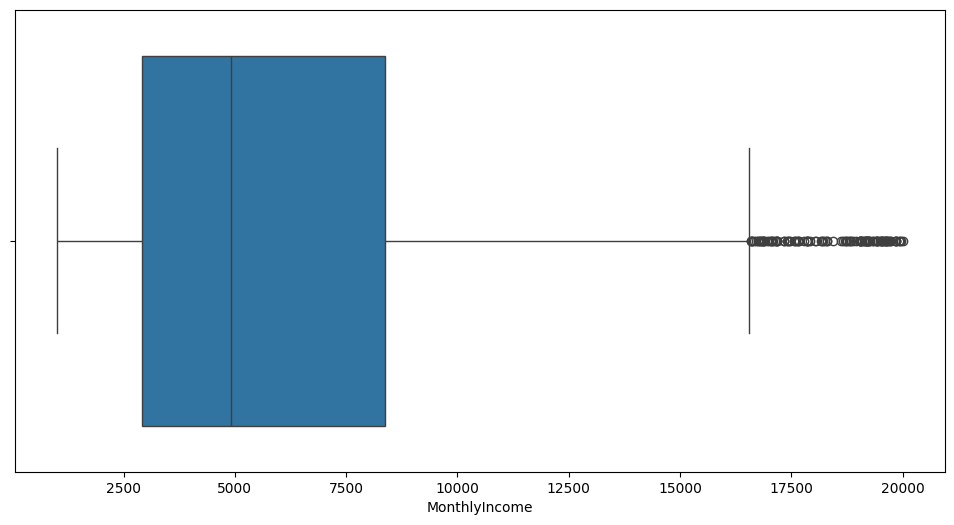

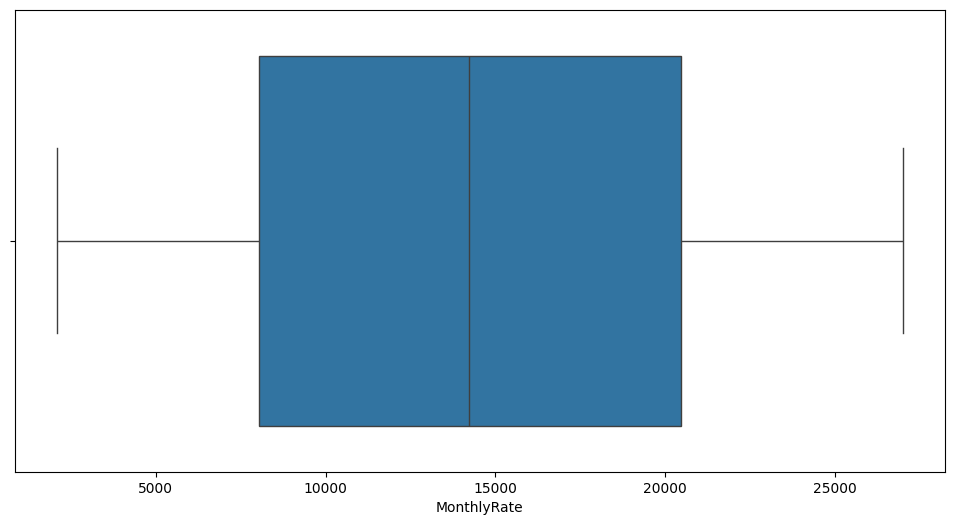

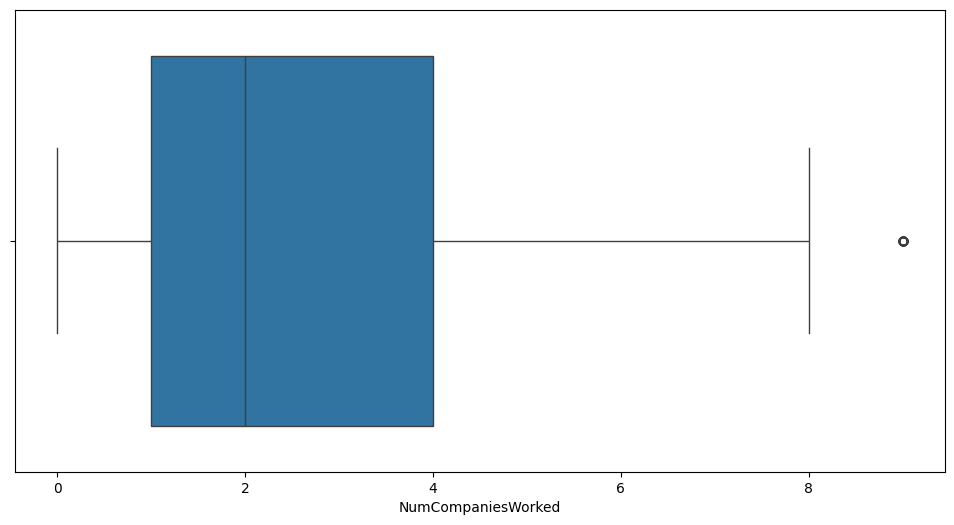

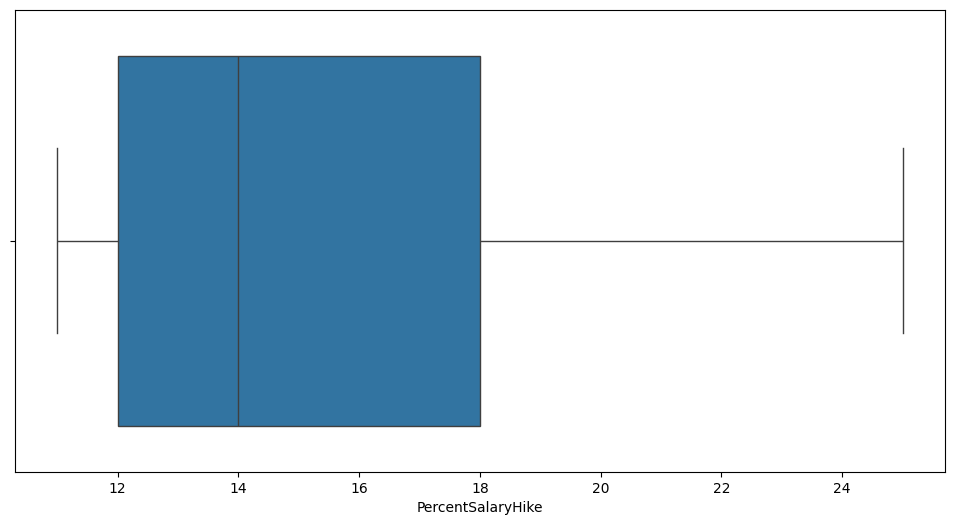

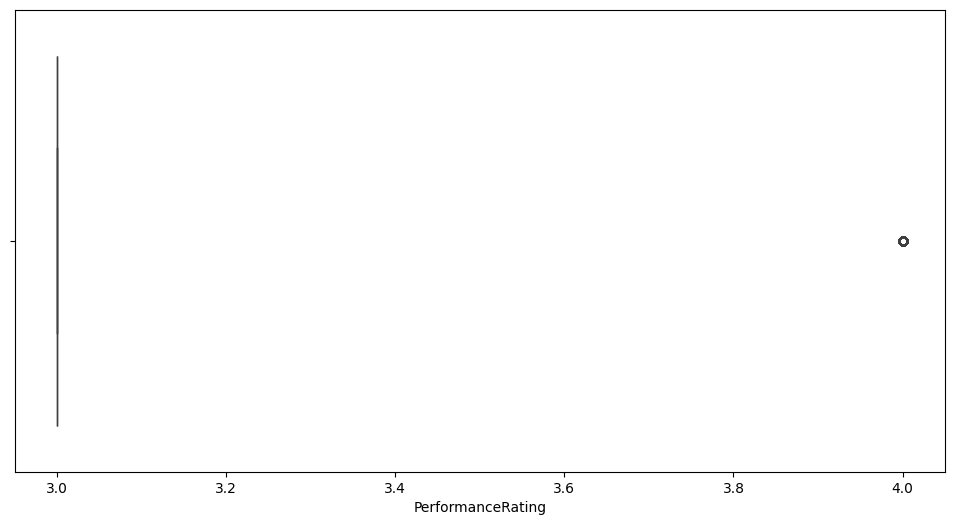

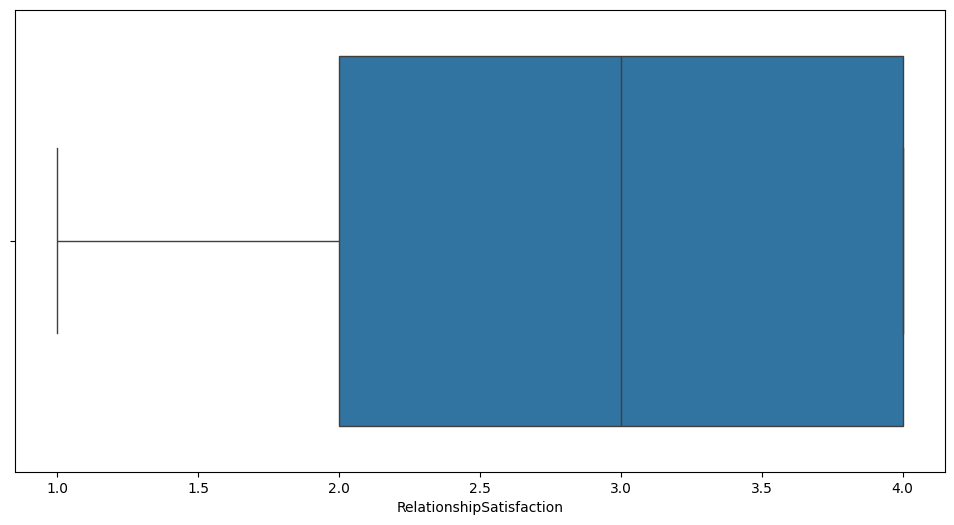

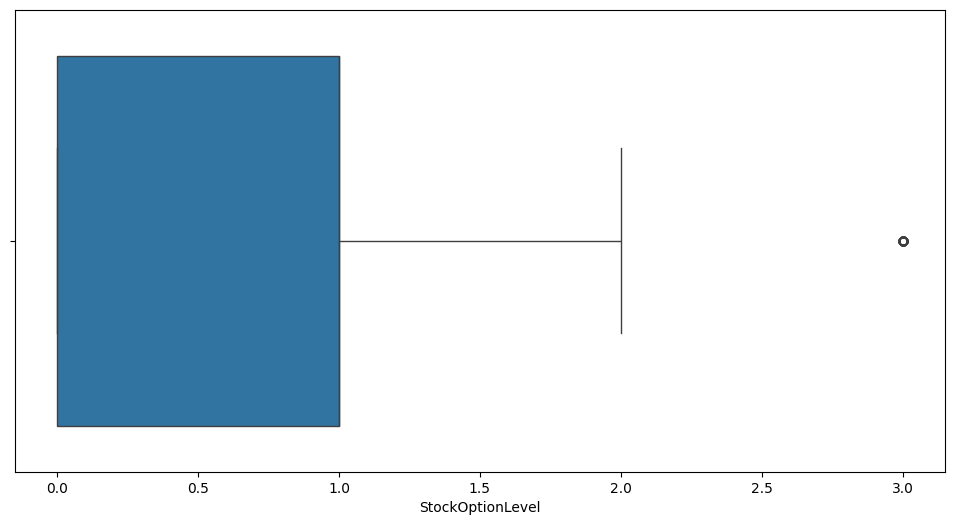

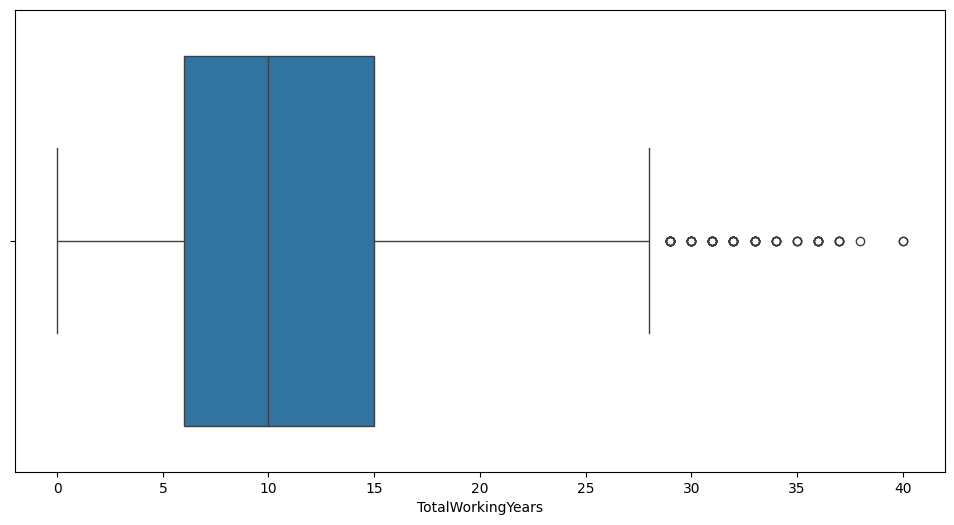

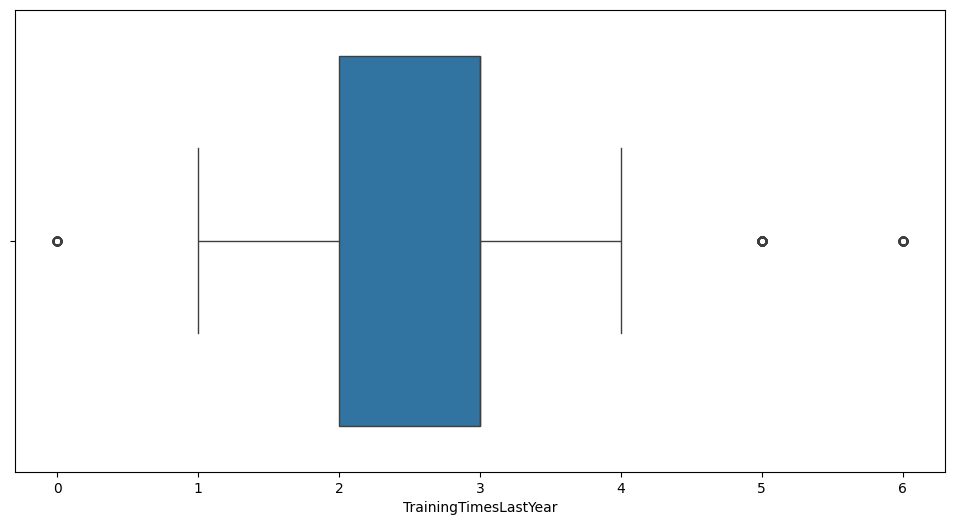

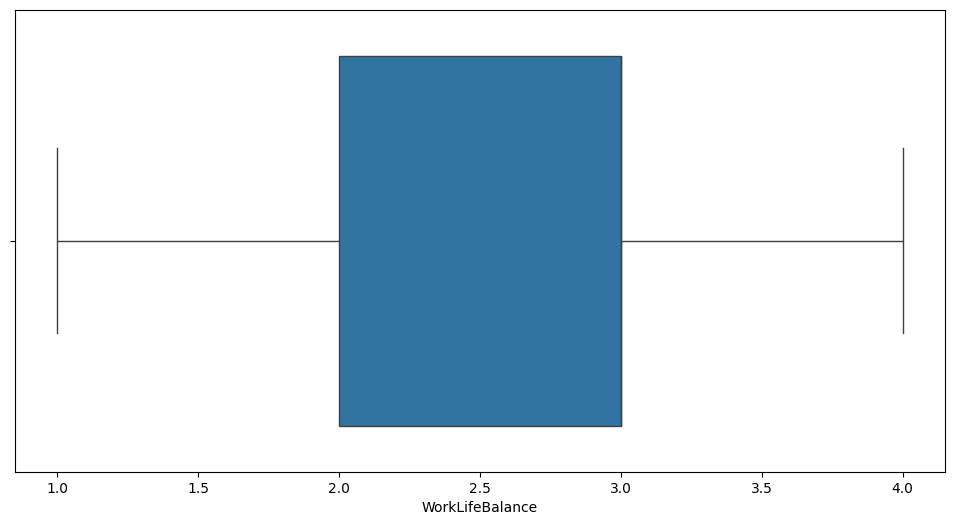

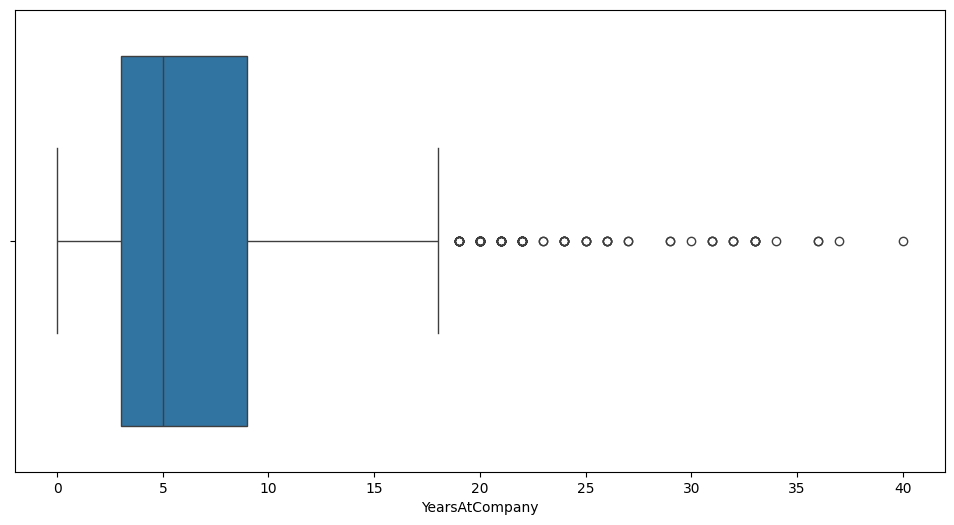

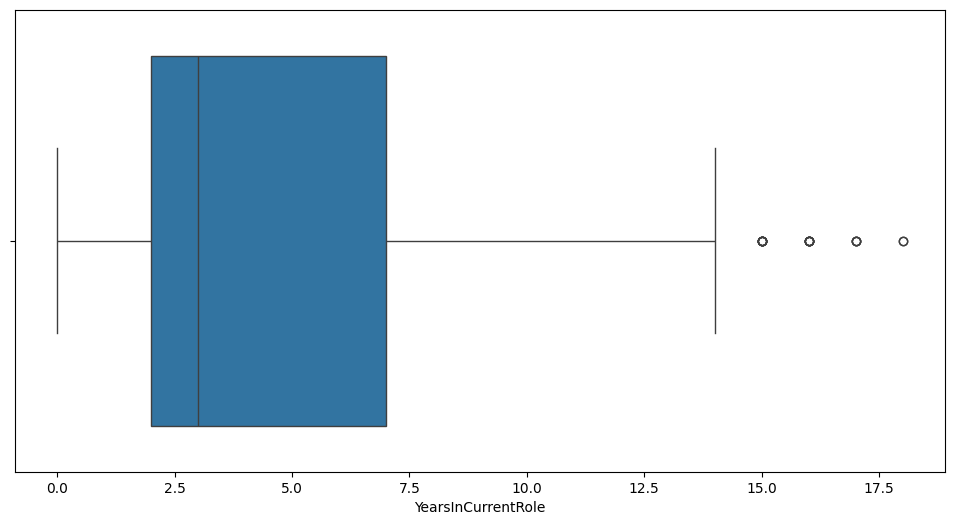

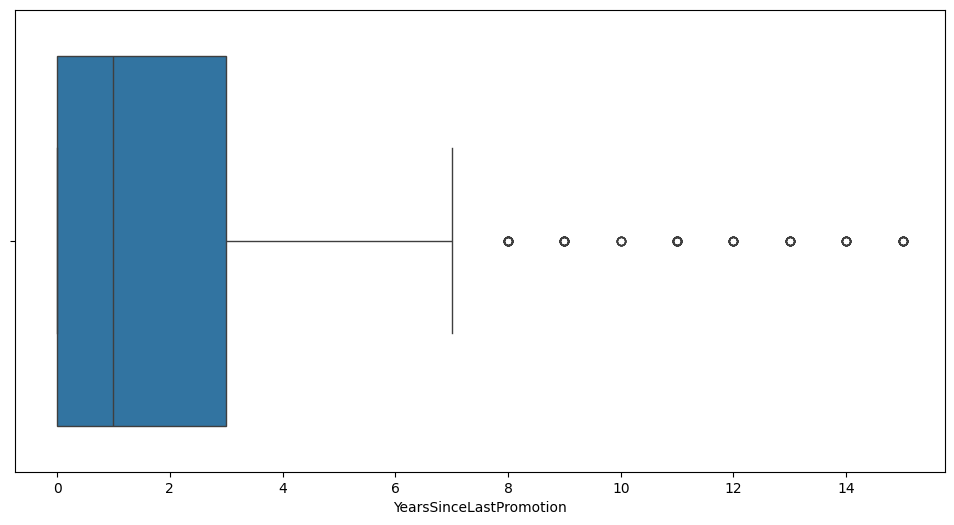

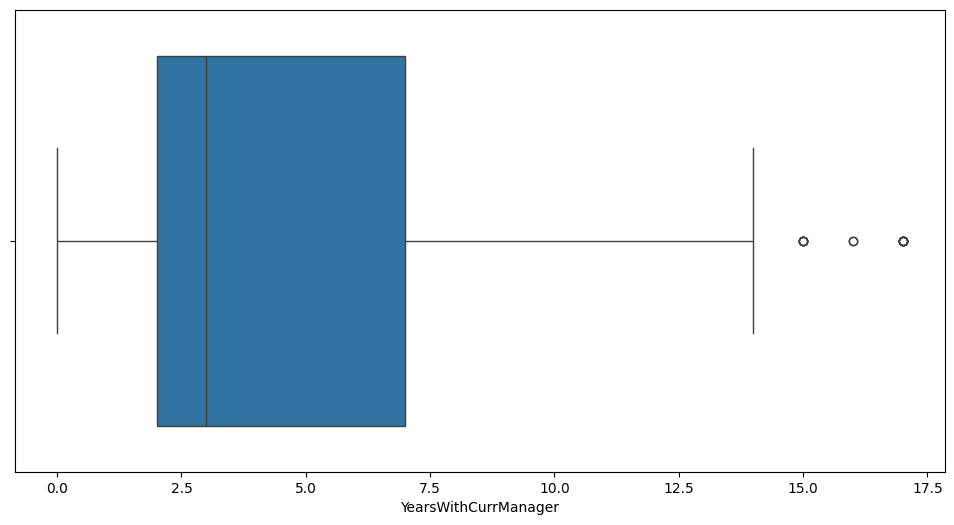

In [350]:
for i in numeric_col:
    plt.figure(figsize=(12,6))
    sns.boxplot(x=df[i])

In [351]:
df['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

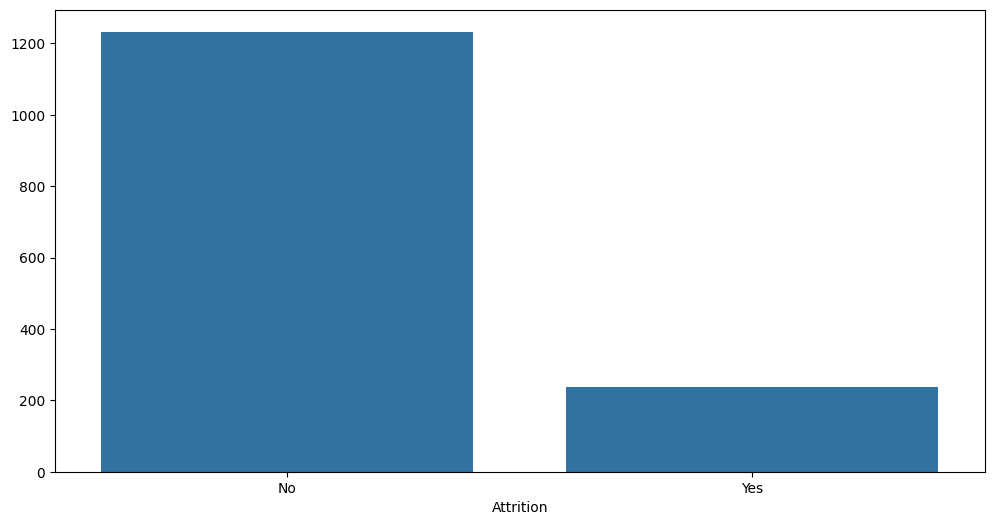

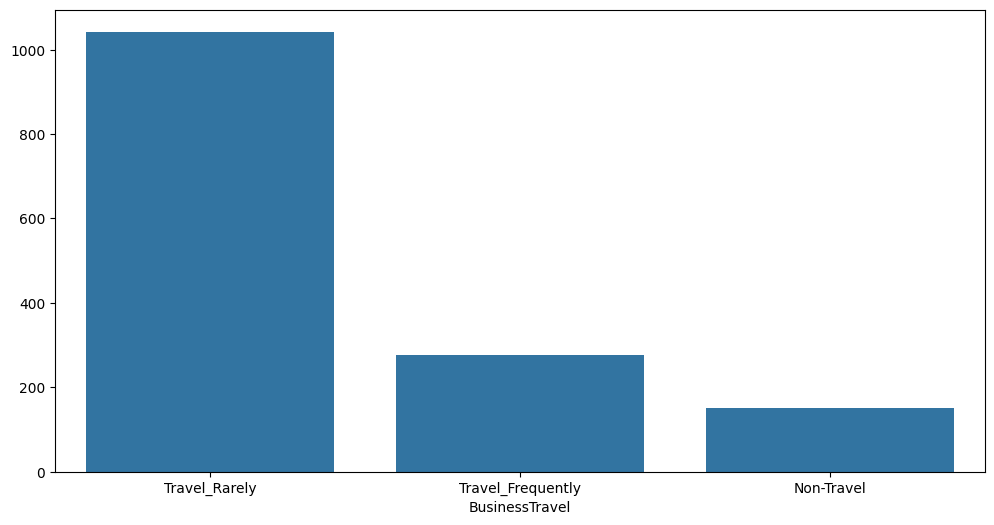

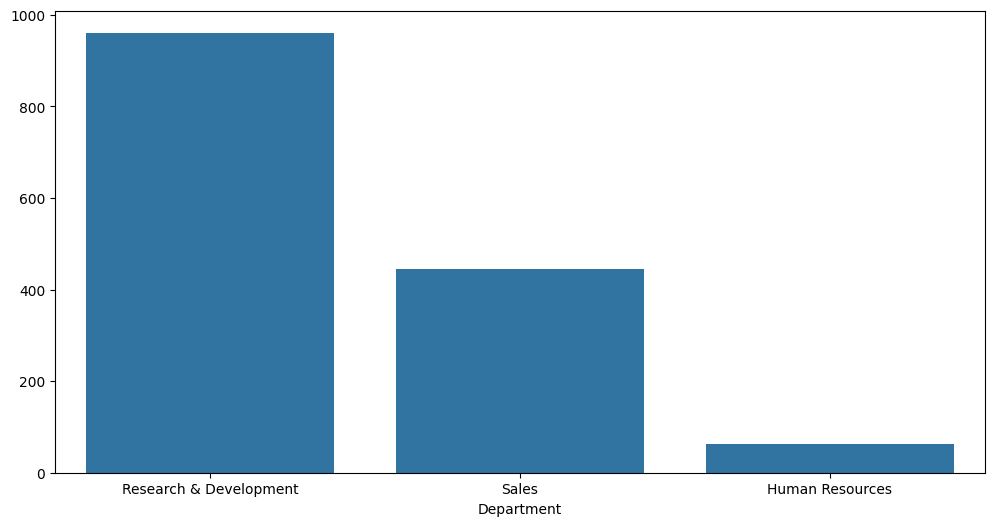

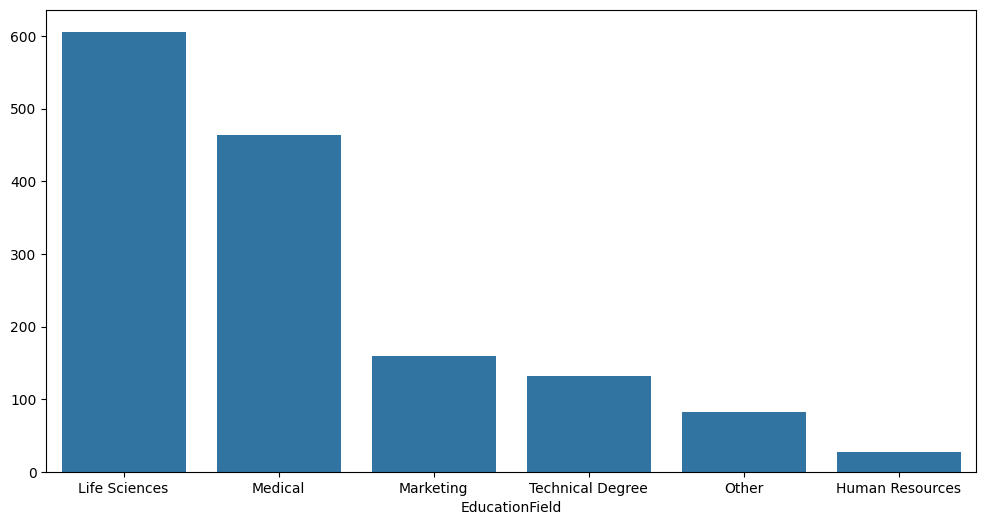

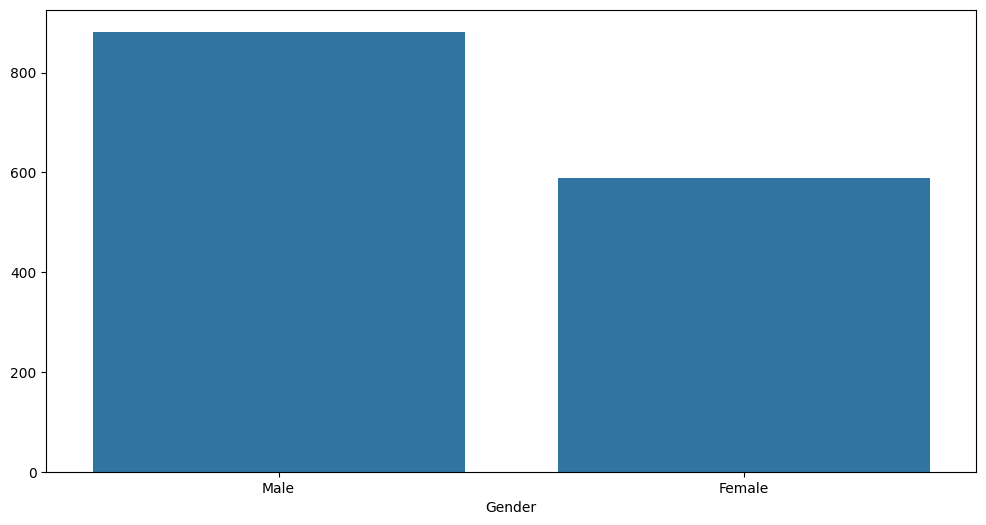

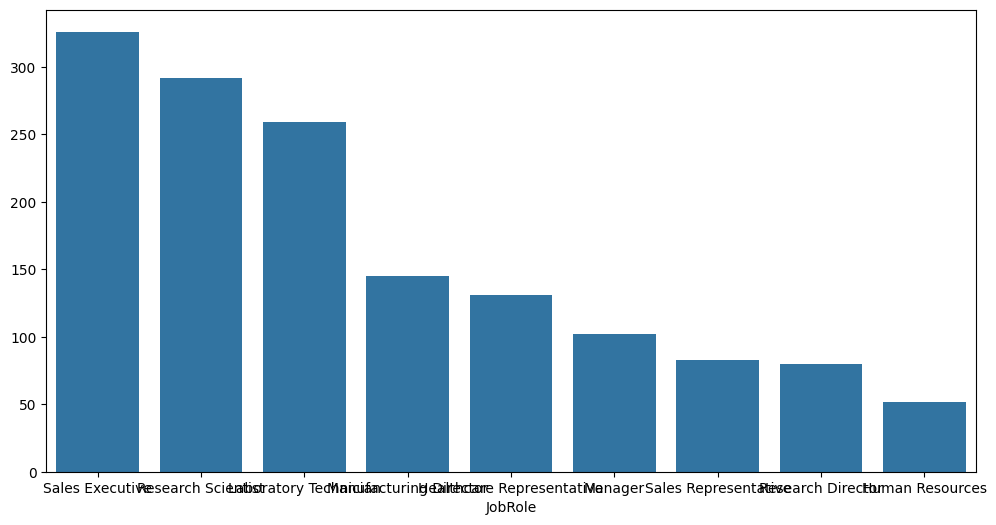

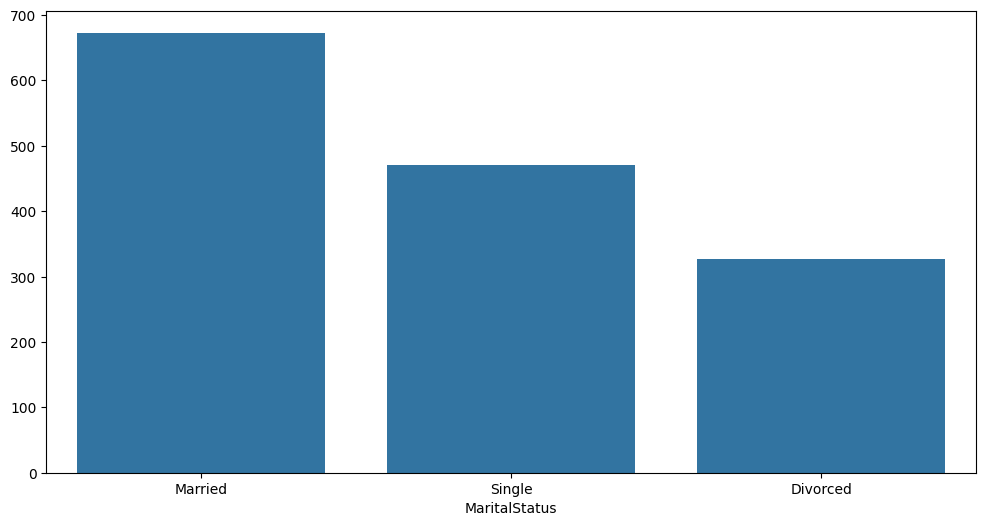

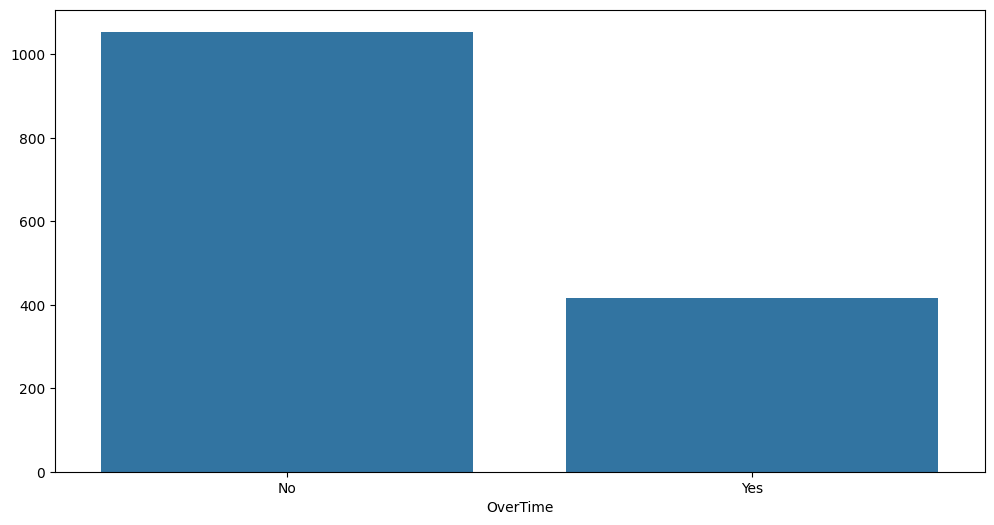

In [352]:
for i in categorical_col :
    plt.figure(figsize=(12,6))
    counts=df[i].value_counts()
    sns.barplot(x=counts.index,y=counts.values)

In [353]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


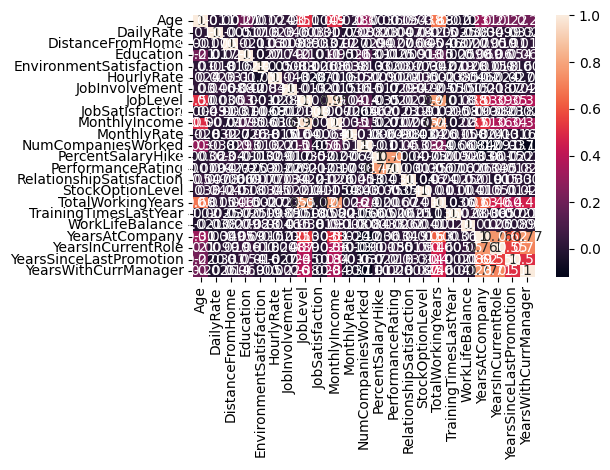

In [354]:
sns.heatmap(df.corr(numeric_only=True),annot=True) 
plt.tight_layout()

In [385]:
df.columns=df.columns.str.strip()
print('available columns :',df.columns.to_list())

available columns : ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Flag']


In [ ]:
df['Attrition_Flag']=df['Attrition'].map({'Yes':1,'No':0})
df=df.drop('Attrition',axis=1)


In [387]:
x=df.drop(columns='Attrition_Flag')
y=df['Attrition_Flag']

In [388]:
cat_cols = x.select_dtypes(include=['category','object']).columns
num_cols = x.select_dtypes(include=['int64','float64']).columns

print(cat_cols)   # check


Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [389]:
categorical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('OneHotEncoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

numeric_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

preprocessor=ColumnTransformer(transformers=[
    ('num',numeric_transformer,num_cols),
    ('col',categorical_transformer,cat_cols)
])


In [390]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)


In [391]:
df.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition_Flag'],
      dtype='object')

In [392]:
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,1,0,8,0,1,6,4,0,5,1
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,4,1,10,3,3,10,7,1,7,0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,2,0,7,3,3,0,0,0,0,1
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3,0,8,3,3,8,7,3,0,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,4,1,6,3,3,2,2,2,2,0


In [393]:
model=LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
model.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [394]:
y_pred=model.predict(X_test)

In [395]:
print("the accuracy of the model is :",accuracy_score(y_test,y_pred))
print("the confusion matrix of the model is :\n",confusion_matrix(y_test,y_pred))
print("the precision of the model is :",precision_score(y_test,y_pred))
print("the classififcation report of the model is :\n",classification_report(y_test,y_pred))
print("the recall of the model is :",recall_score(y_test,y_pred))
print("the F1 Score of the model is :",f1_score(y_test,y_pred))

the accuracy of the model is : 0.7142857142857143
the confusion matrix of the model is :
 [[188  67]
 [ 17  22]]
the precision of the model is : 0.24719101123595505
the classififcation report of the model is :
               precision    recall  f1-score   support

           0       0.92      0.74      0.82       255
           1       0.25      0.56      0.34        39

    accuracy                           0.71       294
   macro avg       0.58      0.65      0.58       294
weighted avg       0.83      0.71      0.75       294

the recall of the model is : 0.5641025641025641
the F1 Score of the model is : 0.34375


In [396]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

from sklearn.model_selection import StratifiedKFold,cross_val_score
print('\n validation mean accuracies')
for cv in [5,10,15]:
    skf=StratifiedKFold(n_splits=cv,shuffle=True,random_state=42)
    score=cross_val_score(model,preprocessor.transform(x),y,cv=skf,scoring='accuracy')
    print(f'cv={cv},scores={score.mean()},std:{score.std()}')


 validation mean accuracies
cv=5,scores=0.753061224489796,std:0.018580272494894752
cv=10,scores=0.7578231292517007,std:0.02155507417381612
cv=15,scores=0.7578231292517007,std:0.033836272422982004


In [367]:
pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [401]:
#swot

from imblearn.over_sampling import SMOTE
X_train_raw, X_test_raw, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)



In [402]:
model_sm=LogisticRegression(max_iter=1000,random_state=42)

In [403]:
model_sm.fit(X_train_sm, y_train_sm)
y_pred = model.predict(X_test)   # real unseen data


In [404]:
y_pred1=model_sm.predict(X_test)
accuracy_score(y_pred1,y_test)

0.7721088435374149

In [405]:
X_test

array([[-0.95377387,  0.16419314, -0.52269928, ...,  1.        ,
         1.        ,  0.        ],
       [ 1.76363593,  0.70172863,  0.45884859, ...,  0.        ,
         1.        ,  0.        ],
       [-1.38855944, -1.37937208,  1.56308993, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.43754676,  1.28857931,  2.29925083, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.02449366,  1.04940067,  0.09076814, ...,  1.        ,
         1.        ,  0.        ],
       [ 1.11145758, -1.35718025, -0.89077972, ...,  0.        ,
         0.        ,  1.        ]], shape=(294, 51))

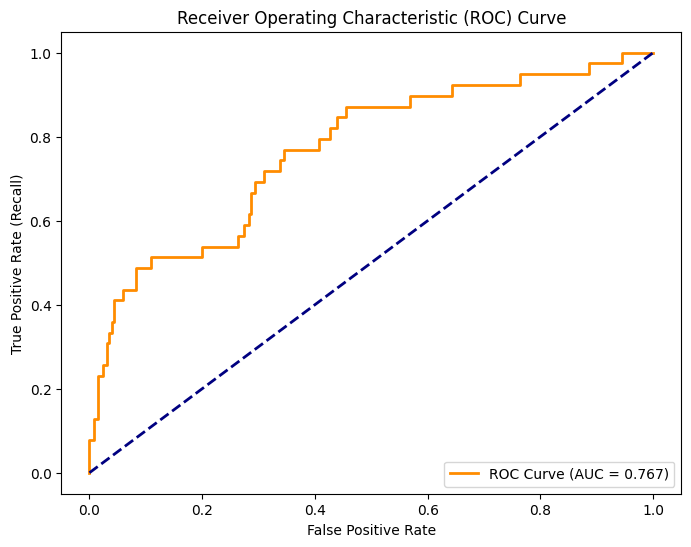

In [406]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores
y_proba = model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')   # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [429]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

pipe=Pipeline(steps=[
    ('pre',preprocessor),
    ('clf',LogisticRegression(max_iter=1000,random_state=42))

])
# Hyperparameter grid
param_grid = {
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__solver': ['liblinear', 'saga'],   # l1 works with liblinear & saga
    'clf__class_weight': [None, 'balanced']
}

# Grid Search
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
# Train
grid.fit(X_train_raw, y_train)

# Results
print("Best Parameters from Grid Search:")
print(grid.best_params_)

print("Best Cross-Validated F1 Score:")
print(grid.best_score_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters from Grid Search:
{'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Best Cross-Validated F1 Score:
0.5280018528462428


In [430]:
# Randomized Search
random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=20,        # number of random combinations
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Train
random_search.fit(X_train_raw, y_train)

# Best results
print("Best Parameters:", random_search.best_params_)
print("Best CV F1 Score:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'clf__solver': 'saga', 'clf__penalty': 'l1', 'clf__class_weight': None, 'clf__C': 1}
Best CV F1 Score: 0.5280018528462428


In [431]:
# Best model from RandomizedSearchCV or GridSearchCV
best_model1= random_search.best_estimator_   # or grid.best_estimator_

# Train best model on full training data
best_model1.fit(X_train_raw, y_train)

# Predictions
y_pred_best = best_model1.predict(X_test_raw)
y_proba_best = best_model1.predict_proba(X_test_raw)[:, 1]


In [432]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Final Tuned Model Performance:")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_best):.4f}")


Final Tuned Model Performance:
Accuracy  : 0.8912
Precision : 0.6207
Recall    : 0.4615
F1 Score  : 0.5294
ROC-AUC   : 0.7923


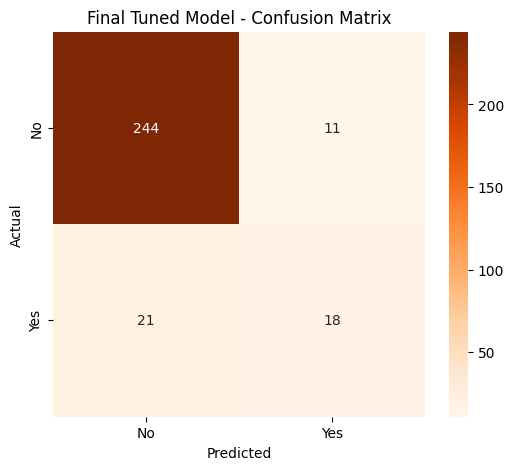

In [425]:
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title("Final Tuned Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [433]:
# Best model from RandomizedSearchCV or GridSearchCV
best_model2 =grid.best_estimator_  # or grid.best_estimator_

# Train best model on full training data
best_model2.fit(X_train_raw, y_train)

# Predictions
y_pred_best1= best_model2.predict(X_test_raw)
y_proba_best1 = best_model2.predict_proba(X_test_raw)[:, 1]

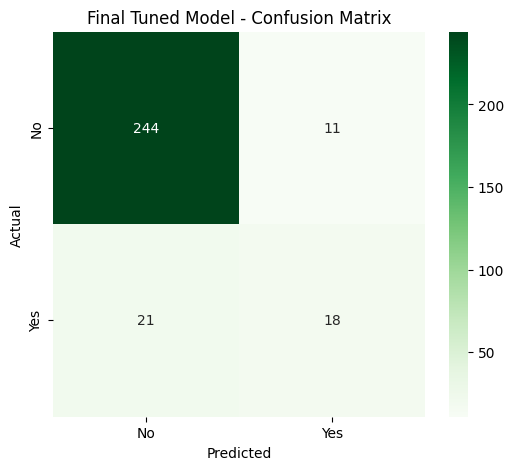

In [434]:
cm_best = confusion_matrix(y_test, y_pred_best1)

plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title("Final Tuned Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [435]:

print("Final Tuned Model Performance:")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best1):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best1):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best1):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_best1):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_best):.4f}")


Final Tuned Model Performance:
Accuracy  : 0.8912
Precision : 0.6207
Recall    : 0.4615
F1 Score  : 0.5294
ROC-AUC   : 0.7923
